In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
import re
import os
import numpy as np


parsing mot and sto files

In [15]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    wn = cutoff / nyq
    b, a = butter(order, wn, btype='low')
    return filtfilt(b, a, data, axis=0)

In [16]:
def dataframe(filePath, cutoff = 10):
    header_index = 0
    with open(filePath, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if "endheader" in line:
            header_index = lines.index(line) + 1
            break
    df = pd.read_csv(filePath, sep='\t', skiprows=header_index)
    df.iloc[1:, 1:] = butter_lowpass_filter(df.iloc[1:,1:].astype(float).values, cutoff=10, fs=1000)
    return df

filter grf file

In [17]:
def read_mot_with_header(path):
    with open(path, 'r') as f:
        lines = f.readlines()
    # find endheader index
    header_idx = next((i for i,l in enumerate(lines) if 'endheader' in l.lower()), None)
    if header_idx is None:
        raise ValueError("No 'endheader' found in file")
    header_lines = lines[:header_idx+1]      # include the 'endheader' line
    colnames_line = lines[header_idx+1].rstrip("\n")
    # load data (pandas will use the next line as column names)
    df = pd.read_csv(path, sep=r'\s+', engine='python', skiprows=header_idx+1)
    return header_lines, colnames_line, df

def detect_y_columns(df):
    cols = []
    for c in df.columns:
        low = c.lower()
        if re.search(r'(_vy$|_fy$|vy$|fy$)', low) or ('ground_force' in low and 'vy' in low):
            cols.append(c)
    return cols

def filter_file(in_path,
                        out_path=None,
                        cutoff=10.0,
                        order=6,
                        fs=None,
                        fs_fallback=1000.0,
                        # columns=["ground_force_1_px","ground_force_1_py","ground_force_1_pz"],
                        plot=False):
    """
    Read `in_path` (.mot/.sto), low-pass filter Y-GRF columns, and save to `out_path`
    preserving the original header and column-label line.
    If out_path is None, a new file `<inname>_filtered.mot` is created next to input.
    """
    header_lines, colnames_line, df = read_mot_with_header(in_path)

    # if columns is None:
    #     columns = detect_y_columns(df)
    # if not columns:
    #     raise ValueError("No Y-direction GRF columns detected. Provide `columns=` explicitly.")

    # estimate fs if not provided
    time_col = next((c for c in df.columns if c.lower() == 'time'), df.columns[0])
    time = df[time_col].values
    if fs is None:
        if len(time) >= 2:
            dt = np.mean(np.diff(time))
            fs = 1.0 / dt
        else:
            fs = fs_fallback

    # prepare numeric matrix and filter
    data_mat = df.iloc[:,1:].astype(float).values
    filtered_mat = butter_lowpass_filter(data_mat, cutoff=cutoff, fs=fs, order=order)

    # place filtered values back into dataframe copy
    df_filt = df.copy()
    df_filt.iloc[:, 1:] = filtered_mat

    # choose output path
    if out_path is None:
        base, ext = os.path.splitext(in_path)
        out_path = base + '_filtered' + (ext if ext else '.mot')

    # write header + original column label line + filtered data (no pandas header)
    with open(out_path, 'w', newline='\n') as f:
        f.writelines(header_lines)
        f.write(colnames_line + '\n')
    # append data without header (tab-separated for readability)
    df_filt.to_csv(out_path, sep='\t', index=False, header=False, float_format='%.6f', mode='a')
    # print(f"Saved filtered .mot to: {out_path}")

    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,6))
        for c in df.columns[1:]:  # skip time column
            plt.plot(time, df_filt[c].values, label=c)
        plt.xlabel('Time (s)')
        plt.ylabel('Force (N)')
        plt.title('Filtered GRF Y-direction (combined)')
        plt.legend(fontsize='small')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return df_filt, out_path

marking subjects as young middle and older

In [18]:
age_group = {"young" : [8,6,23,3,17,35],
            "middle" : [29,65,52,34,30,43],
            "older" : [53,55,45,54,42,56]}

## detecting initiation

using fy(t) - fy(baseline of ~ 1sec) > 2*SD(baseline)

In [19]:
def detect_intiation_force(mot_file):
    df = filter_file(mot_file)[0]
    frame_at_1s = (df["time"]-1.0).abs().idxmin()
    fz_base = sum(df["ground_force_1_vy"][:frame_at_1s])/frame_at_1s
    baseline_std = np.std(df["ground_force_1_vy"][:frame_at_1s])
    threshold = fz_base + 2 * baseline_std

    mask = df["ground_force_1_vy"] > threshold
    initiation_frame = mask.idxmax()
    return initiation_frame

itiation frame using cop

In [20]:
#
def detect_intiation_cop(mot_file):
    df = filter_file(mot_file)[0]
    frame_at_1s = (df["time"]-1.0).abs().idxmin()
    fz_base = sum(df["ground_force_1_py"][:frame_at_1s])/frame_at_1s
    baseline_std = np.std(df["ground_force_1_py"][:frame_at_1s])

    mask = (df["ground_force_1_py"] - fz_base ).abs()> baseline_std
    initiation_frame = mask.idxmax()
    return initiation_frame

# detect end frame

In [21]:
# Detect heel strike and toe off events from vertical GRF
def detect_gait_end(grf_file, fs=1000, cutoff=20, threshold=20, min_width=15):
    # ==============================
    # USER INPUTS
    # ==============================
    # grf_file = '../donottouch/stw1.mot'   # your force plate file
    # fs = 1000                     # sampling frequency (Hz)
    # cutoff = 20                  # Butterworth cutoff frequency (Hz)
    # threshold = 20               # force threshold (N)
    # min_width = 15               # minimum width in samples

    # ==============================
    # READ OpenSim .sto FILE
    # ==============================
    with open(grf_file, 'r') as f:
        for i, line in enumerate(f):
            if 'endheader' in line.lower():
                header_line = i
                break

    data = pd.read_csv(
        grf_file,
        sep=r'\s+',
        skiprows=header_line + 1
    )

    time = data['time'].values
    vy_raw = data['ground_force_3_vy'].values  # vertical GRF

    # ==============================
    # BUTTERWORTH FILTER (zero-phase)
    # ==============================
    b, a = butter(
        N=4,
        Wn=cutoff / (fs / 2),
        btype='low'
    )

    vy_filt = filtfilt(b, a, vy_raw)

    # ==============================
    # GAIT EVENT DETECTION
    # ==============================
    above = vy_filt > threshold

    HS_idx = []
    TO_idx = []

    i = 0
    while i < len(above) - min_width:
        # Heel Strike: below → above threshold for >= min_width samples
        if not above[i] and all(above[i+1:i+1+min_width]):
            HS_idx.append(i + 1)
            i += min_width
            continue

        # Toe Off: above → below threshold for >= min_width samples
        if above[i] and all(~above[i+1:i+1+min_width]):
            TO_idx.append(i + 1)
            i += min_width
            continue

        i += 1

    HS_times = time[HS_idx]
    TO_times = time[TO_idx]
    # print(TO_idx[0]//5)
    return TO_idx[0]//5

    # ==============================
    # PLOT
    # ==============================
    # plt.figure(figsize=(10, 5))

    # plt.plot(time, vy_filt, label='Vertical GRF (filtered)', color='black')
    # plt.axhline(threshold, linestyle='--', color='gray', label='20 N Threshold')

    # plt.scatter(HS_times, vy_filt[HS_idx],
    #             color='green', label='Heel Strike', zorder=3)

    # plt.scatter(TO_times, vy_filt[TO_idx],
    #             color='red', label='Toe Off', zorder=3)

    # plt.xlabel('Time (s)')
    # plt.ylabel('Vertical GRF (N)')
    # plt.title('Gait Event Detection from Vertical GRF')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()


# id plot

In [22]:
dataframe(r"d:\RESEARCH\STW_dataset\Extracted\S01\ID\results_ID\id_output_s01_stw1.sto")

,time,pelvis_tilt_moment,pelvis_list_moment,pelvis_rotation_moment,pelvis_tx_force,pelvis_ty_force,pelvis_tz_force,hip_flexion_r_moment,hip_adduction_r_moment,hip_rotation_r_moment,...,knee_angle_r_moment,knee_angle_r_beta_force,knee_angle_l_moment,knee_angle_l_beta_force,ankle_angle_r_moment,ankle_angle_l_moment,subtalar_angle_r_moment,subtalar_angle_l_moment,mtp_angle_r_moment,mtp_angle_l_moment
0,-0.000,-17.131789,0.067731,-0.911745,1.714448,627.908914,-0.604448,28.213132,-3.557606,0.158214,...,2.879336,-0.022554,4.807888,-0.022795,-0.001383,-3.448819,-1.077989,-0.662842,-0.027066,-0.026433
1,0.005,-13.657825,0.148131,0.260567,2.562127,631.014355,-2.302477,28.085790,-2.808753,0.356439,...,3.109145,-0.022538,2.171155,-0.022791,-0.129004,-0.719026,-0.845914,-1.343695,-0.027358,-0.026767
2,0.010,-13.740142,0.154504,0.286107,2.602991,631.016463,-2.483440,28.151259,-2.766287,0.337884,...,3.055115,-0.022539,2.237607,-0.022789,-0.081374,-0.771604,-0.824798,-1.339073,-0.027382,-0.026799
3,0.015,-13.821150,0.161098,0.311371,2.639959,631.016595,-2.660876,28.217200,-2.724186,0.319404,...,3.000752,-0.022540,2.304264,-0.022788,-0.033432,-0.824485,-0.803908,-1.334250,-0.027406,-0.026832
4,0.020,-13.900694,0.167947,0.336327,2.672858,631.014723,-2.834355,28.283491,-2.682520,0.301029,...,2.946155,-0.022541,2.371005,-0.022786,0.014737,-0.877572,-0.783273,-1.329236,-0.027431,-0.026864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,5.600,9.410890,15.990504,2.617915,-86.275556,549.274637,-25.658929,15.992172,-1.049047,-0.663898,...,-4.355681,-0.032852,-2.525222,-0.034853,-18.657567,2.551990,-0.940612,1.027373,-0.072477,-0.039671
1121,5.605,9.451243,15.958600,2.614420,-86.264266,549.781459,-25.708682,16.014256,-1.007576,-0.659280,...,-4.381855,-0.032840,-2.535620,-0.034847,-18.548654,2.557146,-0.936799,1.025468,-0.072521,-0.039680
1122,5.610,9.483972,15.932081,2.611496,-86.253654,550.200485,-25.749515,16.032313,-0.973330,-0.655492,...,-4.403253,-0.032830,-2.544146,-0.034841,-18.458556,2.561413,-0.933630,1.023885,-0.072557,-0.039688
1123,5.615,9.510156,15.910330,2.609083,-86.243953,550.542382,-25.782583,16.046880,-0.945423,-0.652427,...,-4.420512,-0.032821,-2.551044,-0.034837,-18.385002,2.564899,-0.931029,1.022587,-0.072586,-0.039693


In [23]:
joint_l_moments = ["hip_flexion_l_moment", "hip_adduction_l_moment", "hip_rotation_l_moment",
                 "knee_angle_l_moment", 
                 "ankle_angle_l_moment"]
joint_r_moments = ["hip_flexion_r_moment", "hip_adduction_r_moment", "hip_rotation_r_moment",
                 "knee_angle_r_moment",
                    "ankle_angle_r_moment"]
joints = ["hip_flexion", "hip_adduction", "hip_rotation",
                "knee_angle", "ankle_angle"]

which leg to select for analysis by visualization first leg step will be considered.

In [24]:
young_leg = pd.read_csv(rf"young.csv")
middle_leg = pd.read_csv(rf"middle.csv")
older_leg = pd.read_csv(rf"older.csv")
leg = pd.concat([young_leg, middle_leg, older_leg])

fetching the data across all subjects and trial

In [ ]:
def joint_moments_data(subjects):
    
        data_table = {} 
        moment = {}
        trials = {}   
    
        for subject in subjects:
            for trial in range(1,6):
                try:
                    df = dataframe(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\ID\results_ID\id_output_s{subject:02d}_stw{trial}.sto")
                except Exception as e:
                    print(f"Error occurred while loading data for subject {subject}, trial {trial}: {e}")
                    continue
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                start = detect_intiation_force(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
                start = int(start)
                print(f"Subject {subject}, Trial {trial}, Leg {which_leg}, Start Frame: {start}")
                # end = detect_gait_end(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
                # end = int(end)
                if which_leg == 'L':
                    joint_moments = joint_l_moments
                else:
                    joint_moments = joint_r_moments
                # print(joint_moments)
                for joint_moment in joint_moments:
                    moment[joint_moment] = df[joint_moment].values[start:]
                trials[trial] = moment
                moment = {}
            data_table[subject] = trials
            trials = {}

        return data_table
    

In [ ]:
young_force = (joint_moments_data(age_group["young"]))
# middle_force = (joint_moments_data(age_group["middle"]))
# older_force = (joint_moments_data(age_group["older"]))

In [27]:
age_group = {"young" : [8,6,23,3,17,35],
            }

actual Plot

In [29]:

for joint_moment in joints:
    for group in age_group.keys():
        for subject in age_group[group]:
            for trial in range(1,6):
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                
                if which_leg == 'L':
                    foot = "l"
                else:
                    foot = "r"
                data = globals()[f"{group}_force"][subject][trial][f"{joint_moment}_{foot}_moment"]
                
                plt.plot(data)
                plt.savefig(f"D:\\student\\MTech\\graph\\{joint_moment}_{group}_subject{subject}_trial{trial}.png")
                plt.clf()
    # plt.title(f"{joint_moment} across age groups")
    # plt.xlabel("Frames")
    # plt.ylabel("Moment (Nm)")
    # plt.show()        

<Figure size 640x480 with 0 Axes>

# ik plot

In [ ]:
dataframe(r"d:\RESEARCH\STW_dataset\Extracted\S01\IK\results_stw\ik_output_stw1_S01.mot")

,time,pelvis_tilt,pelvis_list,pelvis_rotation,pelvis_tx,pelvis_ty,pelvis_tz,hip_flexion_r,hip_adduction_r,hip_rotation_r,...,subtalar_angle_r,mtp_angle_r,hip_flexion_l,hip_adduction_l,hip_rotation_l,knee_angle_l,knee_angle_l_beta,ankle_angle_l,subtalar_angle_l,mtp_angle_l
0,0.000,17.158590,-0.744742,1.788363,-0.115152,0.653247,-0.180386,57.538025,-3.924063,0.854261,...,-4.952218,-9.832234,56.387060,0.338202,5.341214,87.285167,1.523414,15.459120,-7.935130,-9.832234
1,0.005,17.177070,-0.756810,1.808849,-0.115227,0.653218,-0.180402,57.517220,-3.930665,0.825646,...,-4.992516,-9.715908,56.376836,0.350332,5.369175,87.284067,1.523394,15.473170,-7.970227,-9.715908
2,0.010,17.232069,-0.745971,1.814438,-0.115283,0.653284,-0.180392,57.471175,-3.938560,0.822278,...,-5.062108,-9.691138,56.317047,0.368681,5.372165,87.286761,1.523441,15.360033,-8.100225,-9.691138
3,0.015,17.212250,-0.750457,1.809771,-0.115313,0.653235,-0.180357,57.491777,-3.917758,0.859209,...,-5.054682,-9.611982,56.350567,0.349357,5.357566,87.290187,1.523501,15.371295,-8.093011,-9.611982
4,0.020,17.259914,-0.742386,1.816429,-0.115358,0.653288,-0.180362,57.444411,-3.923888,0.840192,...,-5.116926,-9.581081,56.298543,0.365899,5.355203,87.289613,1.523491,15.258958,-8.210516,-9.581081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,5.600,-1.183092,-4.098490,-5.218651,2.074203,0.948807,-0.116626,14.180733,2.175973,2.561328,...,-18.833598,-7.500000,14.489451,-0.594974,-3.690016,24.486931,0.427378,8.088119,-10.742818,-7.500000
1121,5.605,-1.121351,-4.117376,-5.028676,2.078816,0.949297,-0.116924,14.697076,2.179012,2.474524,...,-18.345557,-7.500000,14.041129,-0.568743,-3.710860,24.327933,0.424603,8.361442,-10.477864,-7.500000
1122,5.610,-1.125520,-4.155948,-4.866350,2.083269,0.949781,-0.117198,15.291305,2.254692,2.473720,...,-18.338011,-7.500000,13.654880,-0.548947,-3.603186,24.127475,0.421104,8.465537,-10.304027,-7.500000
1123,5.615,-1.117243,-4.200650,-4.662263,2.088008,0.950226,-0.117519,15.821861,2.284666,2.450235,...,-18.228862,-7.500000,13.253592,-0.535910,-3.556067,23.957771,0.418142,8.670641,-10.188811,-7.500000


In [ ]:
joint_angle_r = ["hip_flexion_r", "hip_adduction_r", "hip_rotation_r",
               "knee_angle_r", "ankle_angle_r"]
joint_angle_l = ["hip_flexion_l", "hip_adduction_l", "hip_rotation_l",
               "knee_angle_l", "ankle_angle_l"]

fetching the data across all subjects and trial

In [ ]:
def joint_angles_data(subjects):
    
        data_table = {} 
        angle = {}
        trials = {}   
    
        for subject in subjects:
            for trial in range(1,6):
                try:
                     df = dataframe(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\IK\results_stw\ik_output_stw{trial}_S{subject:02d}.mot")
                except Exception as e:
                    print(f"Error occurred while loading data for subject {subject}, trial {trial}: {e}")
                    continue
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                
                if which_leg == 'L':
                    joint_angles = joint_angle_l
                else:
                    joint_angles = joint_angle_r
                # print(joint_moments)
                for joint_angle in joint_angles:
                    angle[joint_angle] = (df[joint_angle].values)
                trials[trial] = angle
                angle = {}
            data_table[subject] = trials
            trials = {}

        return data_table
    

In [ ]:
young_angle = (joint_angles_data(age_group["young"]))
middle_angle = (joint_angles_data(age_group["middle"]))
older_angle = (joint_angles_data(age_group["older"]))

actual Plot

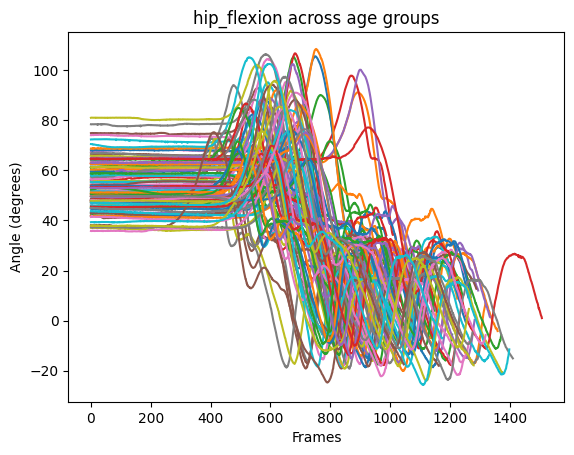

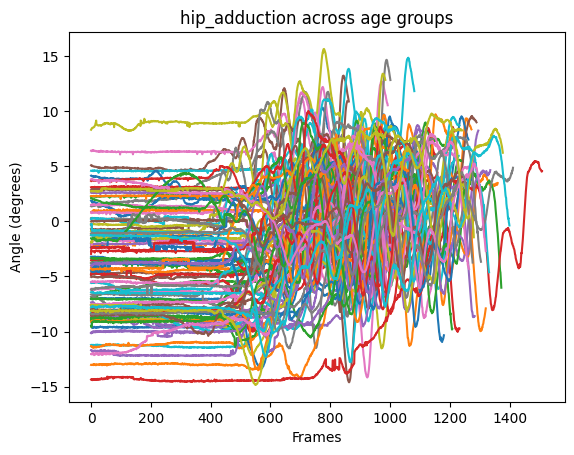

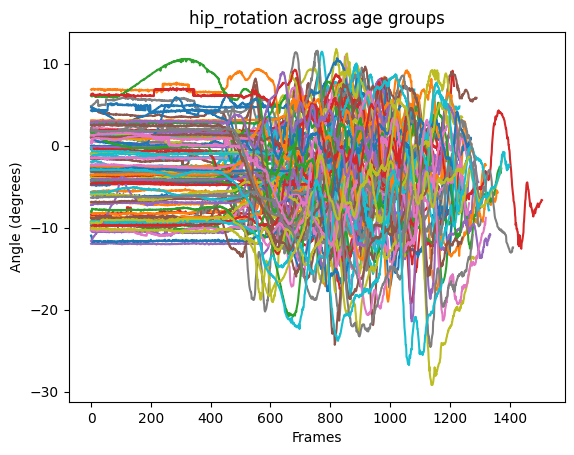

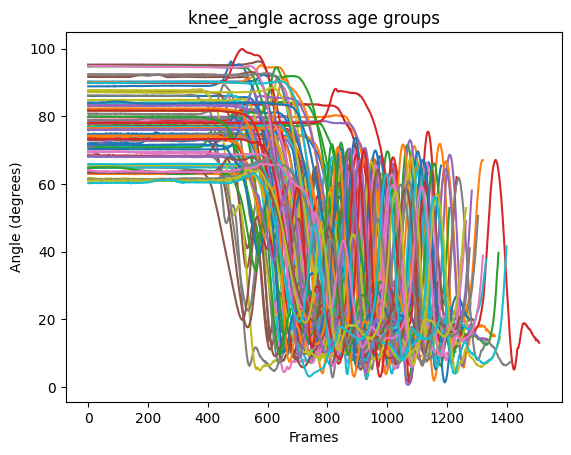

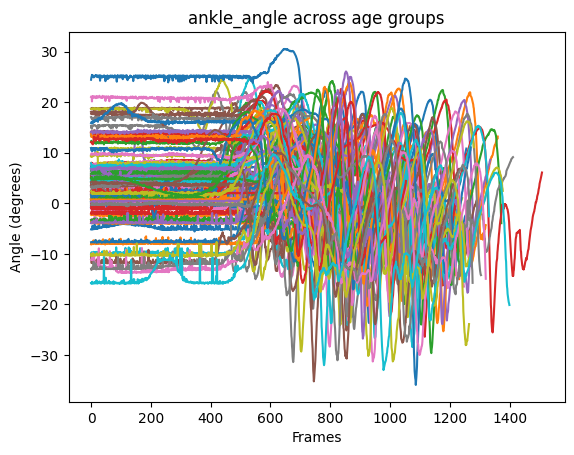

In [ ]:

for joint_angle in joints:
    for group in age_group.keys():
        for subject in age_group[group]:
            for trial in range(1,6):
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                
                if which_leg == 'L':
                    foot = "l"
                else:
                    foot = "r"
                data = globals()[f"{group}_angle"][subject][trial][f"{joint_angle}_{foot}"]
                plt.plot(data)
    plt.title(f"{joint_angle} across age groups")
    plt.xlabel("Frames")
    plt.ylabel("Angle (degrees)")
    plt.show()        